In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image

In [ ]:
class VGG_extractor(nn.Module):

  def __init__(self,content_img,style_img):
    super().__init__()

    self.transforms=T.Compose([
        T.Resize((256,256)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ])

    self.vggnet=models.vgg19(pretrained=True)

    for p in self.vggnet.parameters():
      p.requires_grad=False

    self.content_img,self.style_img,self.target_img=self.prepare(content_img,style_img)


  def prepare(self,content_img,style_img):

    content_img=self.transforms(content_img).unsqueeze(0)
    style_img=self.transforms(style_img).unsqueeze(0)
    target_img=torch.randn(content_img.shape,requires_grad=True)

    return content_img,style_img,target_img

  def extraction(self):





In [6]:
!wget -O content.jpg https://upload.wikimedia.org/wikipedia/commons/6/61/De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg
!wget -O style2.jpg https://upload.wikimedia.org/wikipedia/commons/a/aa/Van_Gogh_-_Starry_Night_2.jpg

--2026-02-26 01:04:36--  https://upload.wikimedia.org/wikipedia/commons/6/61/De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3637889 (3.5M) [image/jpeg]
Saving to: ‘content.jpg’

content.jpg         100%[===================>]   3.47M  --.-KB/s    in 0.1s    

2026-02-26 01:04:36 (28.9 MB/s) - ‘content.jpg’ saved [3637889/3637889]

--2026-02-26 01:04:37--  https://upload.wikimedia.org/wikipedia/commons/a/aa/Van_Gogh_-_Starry_Night_2.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7727745 (7.4M) [image/jpeg]
Saving to: ‘style2.jpg’

style2

In [7]:
content_img_path='/content/style_trans.jpg'
style_img_path='/content/style2.jpg'

content_img=Image.open(content_img_path)
style_img=Image.open(style_img_path)

print(content_img.size,'content')
print(style_img.size,'style')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


(960, 1280) content
(4252, 3367) style


In [82]:
transforms=T.Compose([
        T.Resize((400,400)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ])

tensor_content_img=transforms(content_img).unsqueeze(0).to(device)
tensor_style_img=transforms(style_img).unsqueeze(0).to(device)
tensor_target_img=tensor_content_img.clone().requires_grad_().to(device)

print(f'content_img shape : {tensor_content_img.shape}')
print(f'style_img shape : {tensor_style_img.shape}')
print(f'target_img shape : {tensor_target_img.shape}')


content_img shape : torch.Size([1, 3, 400, 400])
style_img shape : torch.Size([1, 3, 400, 400])
target_img shape : torch.Size([1, 3, 400, 400])


(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

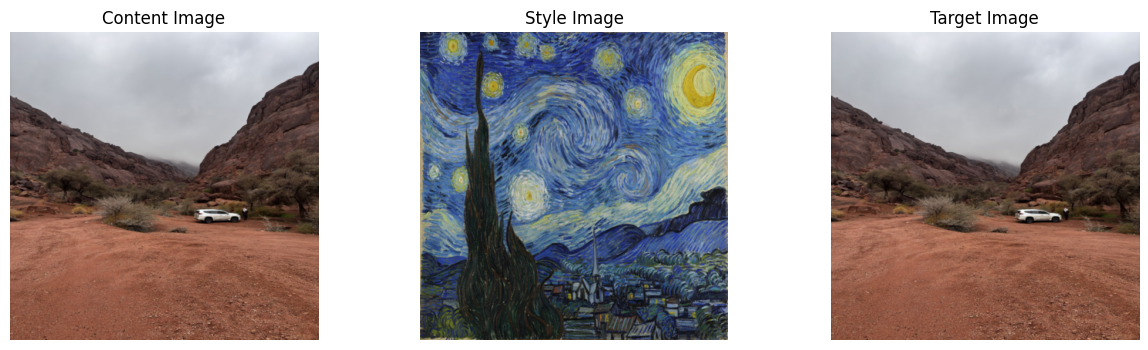

In [67]:
mean=torch.tensor([0.485, 0.456, 0.406])
std=torch.tensor([0.229, 0.224, 0.225])

fix,axis=plt.subplots(1,3,figsize=(15,4))

axis[0].imshow((tensor_content_img).cpu().squeeze().permute(1,2,0)*std+mean)
axis[0].set_title("Content Image")
axis[0].axis("off")

axis[1].imshow((tensor_style_img).cpu().squeeze().permute(1,2,0)*std+mean)
axis[1].set_title("Style Image")
axis[1].axis("off")

axis[2].imshow((tensor_target_img).detach().cpu().squeeze().permute(1,2,0)*std+mean)
axis[2].set_title("Target Image")
axis[2].axis("off")

In [10]:
model=models.vgg19(pretrained=True)
model.to(device)
for parm in model.parameters():
  parm.requires_grad=False

model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [46]:
def features_extractor(x):

  layers={
      'content_layers':[22],
      'style_layers':[1,6,11,20,26]
  }

  features={'content_maps':{},'style_maps':{}}

  for idx,(_,layer) in enumerate(model.features.named_children()):

    x=layer(x)

    if idx in layers['content_layers']:

      features['content_maps'][idx]=x

    elif idx in layers['style_layers']:
      features['style_maps'][idx]=x

  return features['content_maps'],features['style_maps']


def gram_matrix(maps_tensor):
  _,c,w,h=maps_tensor.size()
  features=maps_tensor.view(c,w*h)

  G=features@features.T

  return G/c*w*h

In [65]:
content_maps,_=features_extractor(tensor_content_img)
_,style_maps=features_extractor(tensor_style_img)

style_gram_features={}

for idx in style_maps:

  style_gram_features[idx]=gram_matrix(style_maps[idx])

In [84]:
lossfun =nn.MSELoss()

optimizer=torch.optim.Adam([tensor_target_img],lr=.01)

epochs=1000

content_weight=1
style_weight=1e9

In [85]:
imgs_per_epoch=[]

for epoch in range(epochs):
  style_loss=0
  content_loss=0

  target_content_maps,target_style_maps=features_extractor(tensor_target_img)
  target_gram_features={}

  for idx in target_style_maps:
    target_gram_features[idx]=gram_matrix(target_style_maps[idx])

  optimizer.zero_grad()

  for idx in target_content_maps:
    content_loss+=lossfun(content_maps[idx],target_content_maps[idx])

  for idx in target_style_maps:
    style_gram=style_gram_features[idx]
    target_gram=target_gram_features[idx]
    style_loss+=lossfun(style_gram,target_gram)

  total_loss=(content_loss*content_weight)+(style_loss*style_weight)

  total_loss.backward()

  optimizer.step()

  if epoch % 100 == 0:
      print(f"Epoch {epoch}: Total Loss = {total_loss.item()}")

  with torch.no_grad():

    transed_img=tensor_target_img.detach().cpu().clone()
    imgs_per_epoch.append(transed_img)








Epoch 0: Total Loss = 4.7698613724823004e+24
Epoch 100: Total Loss = 3.259405362469191e+24
Epoch 200: Total Loss = 2.642321132720569e+24
Epoch 300: Total Loss = 2.529752182853766e+24
Epoch 400: Total Loss = 2.492543947135589e+24
Epoch 500: Total Loss = 2.476134991821272e+24
Epoch 600: Total Loss = 2.4670920519998883e+24
Epoch 700: Total Loss = 2.461102913013832e+24
Epoch 800: Total Loss = 2.456659265304701e+24
Epoch 900: Total Loss = 2.453570588593859e+24
